In [1]:
# ================================================================
# BiLSTM + Attention — Train với tiêu đề + 100 từ nội dung
# Input : data_rnn.json  (output của cao_rnn.py)
# Output: model_rnn.keras + artifacts_rnn.pkl
# Chạy trên Google Colab
# ================================================================


# ── CELL 1: CÀI ĐẶT ─────────────────────────────────────────────
!pip install underthesea tensorflow scikit-learn joblib matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 76.6 MB/s eta 0:00:00


In [2]:
# ── CELL 2: IMPORT ──────────────────────────────────────────────
import json
import numpy as np
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from underthesea import word_tokenize
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, hamming_loss,
    roc_curve, auc, classification_report
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:




# ── CELL 3: CẤU HÌNH ────────────────────────────────────────────
# Chỉnh các thông số tại đây, không cần sửa ở chỗ khác

FILE_PATH    = 'data_rnn.json'   # file output của cao_rnn.py
MAX_LEN      = 150               # độ dài chuỗi: tiêu đề ~30 + content ~100 + SEP = ~150
VOCAB_SIZE   = 10000             # giữ 10000 từ phổ biến nhất
EMBED_DIM    = 128               # chiều vector embedding
LSTM_UNITS   = 64                # số unit mỗi chiều LSTM (tổng BiLSTM = 128)
DENSE_UNITS  = 64                # số neuron lớp Dense
DROPOUT_RATE = 0.4               # tỷ lệ dropout
BATCH_SIZE   = 16                # nhỏ vì dataset nhỏ
EPOCHS       = 60                # EarlyStopping sẽ dừng sớm hơn
TEST_SIZE    = 0.15              # 15% dùng để test
VAL_SIZE     = 0.15              # 15% của train dùng để validate

CATEGORIES = ['công nghệ', 'giáo dục', 'giải trí', 'kinh doanh']
NUM_LABELS = len(CATEGORIES)

In [4]:
# ── CELL 4: TIỀN XỬ LÝ VĂN BẢN ─────────────────────────────────
STOPWORDS = {
    "vụ", "bị", "về", "của", "và", "là", "các", "những", "một", "có",
    "đã", "đang", "được", "với", "cho", "ra", "vào", "lộ", "nóng",
    "nhạy_cảm", "sốc", "xôn_xao", "cực_căng", "hot", "đấu_tố",
    "bóc_phốt", "lên_tiếng", "trần_tình", "ồn_ào", "lùm_xùm",
    "nghi_vấn", "tranh_cãi", "bất_ngờ", "mới_nhất", "hiện_nay",
    "hé_lộ", "sự_thật", "theo", "tại", "này", "đó", "khi", "như",
    "thì", "mà", "hay", "hoặc", "nếu", "vì", "do", "qua", "lại"
}

def preprocess(text: str) -> str:
    """
    Tiền xử lý: lower → word_tokenize → bỏ stopwords
    Trả về chuỗi các token cách nhau bằng dấu cách
    """
    tokens = word_tokenize(text.lower(), format="text").split()
    return " ".join(t for t in tokens if t not in STOPWORDS)

def build_input(title: str, content: str) -> str:
    """
    Ghép tiêu đề + nội dung thành 1 chuỗi để train.
    [SEP] là token phân cách để model biết ranh giới.
    Khi predict chỉ dùng tiêu đề, không có [SEP] và content.
    """
    title_proc   = preprocess(title)
    content_proc = preprocess(content) if content else ""
    if content_proc:
        return f"{title_proc} [SEP] {content_proc}"
    return title_proc


In [5]:



# ── CELL 5: NẠP DỮ LIỆU ─────────────────────────────────────────
# Upload data_rnn.json lên Colab trước:
# from google.colab import files
# files.upload()

with open(FILE_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Keyword augmentation — bổ sung mẫu cho nhãn ít dữ liệu
# Chỉ dùng tiêu đề (không có content) vì là mẫu tổng hợp
KEYWORDS = {
    "giáo dục": [
        "nữ sinh", "nam sinh", "thầy giáo", "cô giáo", "giảng viên",
        "học đường", "học sinh", "điểm thi", "gian lận", "trường học",
        "phụ huynh", "kỷ luật", "đình chỉ", "bằng cấp", "học phí",
        "đề thi", "nhà trường", "giáo viên", "sinh viên", "đại học"
    ],
    "công nghệ": [
        "trí tuệ nhân tạo", "chatgpt", "phần mềm", "tiền số", "crypto",
        "hacker", "dữ liệu", "tấn công mạng", "deepfake", "thuật toán",
        "nền tảng số", "robot", "thiết bị thông minh", "ứng dụng",
        "mạng xã hội", "an ninh mạng", "lập trình", "công nghệ số"
    ],
    "giải trí": [
        "nghệ sĩ", "ca sĩ", "hoa hậu", "showbiz", "livestream",
        "tình ái", "ngoại tình", "đấu tố", "sao kê", "từ thiện",
        "fan cuồng", "hợp đồng âm nhạc", "hậu trường", "chia tay",
        "diễn viên", "người mẫu", "youtuber", "tiktoker", "idol",
        "phim ảnh", "âm nhạc", "concert", "drama sao"
    ],
    "kinh doanh": [
        "trái phiếu", "cổ phiếu", "lừa đảo tài chính", "tài sản",
        "giám đốc điều hành", "hợp đồng kinh tế", "bất động sản",
        "chiếm đoạt tài sản", "phá sản", "nợ xấu", "đa cấp",
        "đầu tư tài chính", "lợi nhuận", "vỡ nợ", "ngân hàng",
        "chứng khoán", "startup", "doanh nghiệp", "thâu tóm"
    ]
}

EXTENDED = [
    ("Bị tạm giữ hình sự vì hành vi lừa đảo chiếm đoạt tài sản", "kinh doanh"),
    ("Nghệ sĩ bị bắt vì sử dụng chất cấm tại nhà riêng", "giải trí"),
    ("Nữ sinh lộ clip với thầy giáo trong ký túc xá trường", "giáo dục, giải trí"),
    ("Ca sĩ nổi tiếng bị tố lộ clip nhạy cảm với học sinh", "giải trí, giáo dục"),
    ("Nghệ sĩ làm từ thiện tặng học bổng cho học sinh nghèo", "giải trí, giáo dục"),
    ("Ca sĩ giao lưu biểu diễn tại trường đại học lớn", "giải trí, giáo dục"),
    ("Clip nhạy cảm của người nổi tiếng bị rò rỉ trên mạng", "giải trí"),
    ("Ca sĩ và nữ sinh lộ ảnh riêng tư gây chấn động", "giải trí, giáo dục"),
    ("Nghi vấn ca sĩ có quan hệ bất chính với học sinh trường cấp 3", "giải trí, giáo dục"),
    ("Scandal ca sĩ lộ clip cùng nữ sinh trong khách sạn", "giải trí, giáo dục"),
    ("Đại án kinh tế rúng động cả nước liên quan ngân hàng lớn", "kinh doanh"),
    ("Startup công nghệ Việt Nam gọi vốn triệu đô thành công", "công nghệ, kinh doanh"),
    ("Giáo viên bị tố dâm ô học sinh tại lớp học thêm", "giáo dục"),
    ("Hiệu trưởng bị bắt vì nhận hối lộ và gian lận thi cử", "giáo dục, kinh doanh"),
    ("AI deepfake bị lợi dụng tạo clip giả mạo người nổi tiếng", "công nghệ, giải trí"),
    ("Hacker tấn công hệ thống ngân hàng đánh cắp dữ liệu", "công nghệ, kinh doanh"),
]

# ── Xây dựng X (text) và y (nhãn) ──
X_all, y_all_raw = [], []

# Dữ liệu thật từ data_rnn.json — dùng title + content
for url, item in data.items():
    title   = item.get('title', '')
    content = item.get('content', '')
    tag_str = item.get('tag', '')

    if not title or not tag_str or title.startswith('Lỗi'):
        continue

    combined = build_input(title, content)
    tags = [t.strip().lower() for t in tag_str.split(',')]

    X_all.append(combined)
    y_all_raw.append(tags)

n_real = len(X_all)
print(f"Dữ liệu thật: {n_real} bài")

# Keyword augmentation — chỉ dùng tiêu đề ngắn
for tag, words in KEYWORDS.items():
    for word in words:
        X_all.append(preprocess(f"Thông tin về {word} gây chú ý"))
        y_all_raw.append([tag])

for title, tag_str in EXTENDED:
    X_all.append(preprocess(title))
    y_all_raw.append([t.strip().lower() for t in tag_str.split(',')])

print(f"Sau augmentation : {len(X_all)} mẫu  (+{len(X_all)-n_real} mẫu tổng hợp)")

# MLB
mlb = MultiLabelBinarizer(classes=CATEGORIES)
y_all = mlb.fit_transform(y_all_raw)
print(f"Nhãn: {mlb.classes_}")

# Phân phối nhãn
label_counts = y_all.sum(axis=0)
for cat, cnt in zip(mlb.classes_, label_counts):
    print(f"  {cat:<15}: {int(cnt)} mẫu")

# Train / Test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, random_state=42
)
print(f"\nTrain: {len(X_train_raw)} | Test: {len(X_test_raw)}")



Dữ liệu thật: 74 bài
Sau augmentation : 170 mẫu  (+96 mẫu tổng hợp)
Nhãn: ['công nghệ' 'giáo dục' 'giải trí' 'kinh doanh']
  công nghệ      : 21 mẫu
  giáo dục       : 103 mẫu
  giải trí       : 33 mẫu
  kinh doanh     : 24 mẫu

Train: 144 | Test: 26


In [6]:

# ── CELL 6: TOKENIZE & PADDING ──────────────────────────────────
# Fit tokenizer chỉ trên tập train để tránh data leakage
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token='<OOV>',    # từ không có trong vocab → token đặc biệt
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
)
tokenizer.fit_on_texts(X_train_raw)

X_train_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_train_raw),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
X_test_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_test_raw),
    maxlen=MAX_LEN, padding='post', truncating='post'
)

actual_vocab = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)
print(f"Vocab thực tế : {actual_vocab} từ")
print(f"X_train shape : {X_train_seq.shape}")   # (n, 150)
print(f"X_test  shape : {X_test_seq.shape}")

# Ví dụ minh họa 1 mẫu
print(f"\nVí dụ mẫu đầu tiên:")
print(f"  Text    : {X_train_raw[0][:80]}...")
print(f"  Sequence: {X_train_seq[0][:15]}... (shape {X_train_seq[0].shape})")
print(f"  Nhãn    : {mlb.inverse_transform(y_train[0].reshape(1,-1))[0]}")


Vocab thực tế : 1031 từ
X_train shape : (144, 150)
X_test  shape : (26, 150)

Ví dụ mẫu đầu tiên:
  Text    : thông_tin gian_lận gây chú_ý...
  Sequence: [  5   6 232 531   7  10   9   0   0   0   0   0   0   0   0]... (shape (150,))
  Nhãn    : ('giáo dục',)


In [7]:


# ── CELL 7: CUSTOM ATTENTION LAYER ──────────────────────────────
class AttentionLayer(tf.keras.layers.Layer):
    """
    Soft Attention:
    - Học trọng số (weight) cho từng timestep (từng từ)
    - Các từ quan trọng hơn sẽ có weight cao hơn
    - Tóm tắt toàn bộ chuỗi thành 1 context vector
    - Trả về (context_vector, attention_weights) để có thể visualize
    """
    supports_masking = True          # ← thêm dòng này

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='glorot_uniform', name='attn_W')
        self.b = self.add_weight(shape=(1,),
                                 initializer='zeros', name='attn_b')
        super().build(input_shape)

    def call(self, x, mask=None):
        score = tf.nn.tanh(tf.matmul(x, self.W) + self.b)   # (batch, MAX_LEN, 1)

        # ── xử lý mask ──────────────────────────────────────
        if mask is not None:
            # mask shape: (batch, MAX_LEN) — True=từ thật, False=padding
            # Gán score = -inf cho padding → softmax sẽ cho weight ≈ 0
            mask = tf.cast(mask, tf.float32)               # True/False → 1.0/0.0
            mask = tf.expand_dims(mask, -1)                # (batch, MAX_LEN, 1)
            score = score * mask + (1.0 - mask) * (-1e9)  # padding → -∞
        # ────────────────────────────────────────────────────

        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(x * weights, axis=1)
        return context, weights

    def get_config(self):
        return super().get_config()

In [8]:



# ── CELL 8: BUILD MODEL ──────────────────────────────────────────
#
# KIẾN TRÚC (từ ngoài vào trong):
#
# INPUT (batch, 150)
#   → Embedding       (batch, 150, 128)   học vector từ
#   → SpatialDropout  chống overfit embedding
#   → BiLSTM(64)      (batch, 150, 128)   hiểu ngữ cảnh 2 chiều
#   → Dropout         chống overfit LSTM
#   → Attention       (batch, 128)        tóm tắt câu
#   → Dense(64, relu) (batch, 64)         học pattern phân loại
#   → Dropout         chống overfit Dense
#   → Dense(4, sigmoid)(batch, 4)         xác suất 4 nhãn
# OUTPUT (batch, 4)  — mỗi giá trị ∈ [0,1]

def build_model(vocab_size, embed_dim, max_len, lstm_units,
                dense_units, dropout_rate, num_labels):

    inputs = layers.Input(shape=(max_len,), name='input')

    # LAYER 1 — Embedding
    # Biến mỗi số nguyên (index từ) thành vector embed_dim chiều
    # trainable=True: học embedding từ đầu cùng với model
    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        mask_zero=False,       # bỏ qua padding token (index=0) khi tính loss
        trainable=True,
        name='embedding'
    )(inputs)

    # LAYER 2 — SpatialDropout1D
    # Tắt ngẫu nhiên toàn bộ vector của 1 từ (hiệu quả hơn Dropout thường cho NLP)
    x = layers.SpatialDropout1D(0.3, name='spatial_dropout')(x)

    # LAYER 3 — Bidirectional LSTM
    # Xuôi: đọc "Phạm Thoại ... youtuber" từ trái sang phải
    # Ngược: đọc "youtuber ... Phạm Thoại" từ phải sang trái
    # → hiểu ngữ cảnh đầy đủ cả 2 chiều
    x = layers.Bidirectional(
        layers.LSTM(
            lstm_units,
            return_sequences=True,  # trả về output mỗi timestep cho Attention
            recurrent_dropout=0.2   # dropout bên trong LSTM cell
        ),
        name='bilstm'
    )(x)

    # LAYER 4 — Dropout
    x = layers.Dropout(dropout_rate, name='dropout_1')(x)

    # LAYER 5 — Attention
    # Học từ nào trong câu quan trọng nhất cho việc phân loại
    context, _ = AttentionLayer(name='attention')(x)

    # LAYER 6 — Dense(64, relu)
    x = layers.Dense(dense_units, activation='relu', name='dense_1')(context)

    # LAYER 7 — Dropout
    x = layers.Dropout(dropout_rate, name='dropout_2')(x)

    # OUTPUT LAYER — Dense(4, sigmoid)
    # sigmoid (không phải softmax) vì multi-label:
    # mỗi nhãn độc lập, tổng xác suất không cần = 1
    outputs = layers.Dense(num_labels, activation='sigmoid', name='output')(x)

    return Model(inputs=inputs, outputs=outputs)


model = build_model(
    vocab_size   = actual_vocab,
    embed_dim    = EMBED_DIM,
    max_len      = MAX_LEN,
    lstm_units   = LSTM_UNITS,
    dense_units  = DENSE_UNITS,
    dropout_rate = DROPOUT_RATE,
    num_labels   = NUM_LABELS
)

model.summary()

# Tóm tắt số tham số
total_params = model.count_params()
print(f"\nTổng tham số: {total_params:,}")
print(f"Tỷ lệ tham số/mẫu train: {total_params/len(X_train_raw):.0f}x  (lý tưởng < 100x)")



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 150, 128)       │       131,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 150, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 150, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ [(None, 128), (None,   │           129 │
│                                 │ 150, 1)]               │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 239,429 (935.27 KB)

 Trainable params: 239,429 (935.27 KB)

 Non-trainable params: 0 (0.00 B)


Tổng tham số: 239,429
Tỷ lệ tham số/mẫu train: 1663x  (lý tưởng < 100x)


In [9]:

# ── CELL 9: LOSS & COMPILE ──────────────────────────────────────
# Weighted loss để xử lý mất cân bằng nhãn
# Nhãn ít mẫu (giải trí=17) sẽ được tăng weight để model chú ý hơn

label_freq   = y_train.sum(axis=0).astype(np.float32)
label_weights = (len(y_train) / (NUM_LABELS * np.maximum(label_freq, 1))).astype(np.float32)

print("Label weights (nhãn ít mẫu → weight cao):")
for cat, w in zip(mlb.classes_, label_weights):
    print(f"  {cat:<15}: {w:.3f}")

def weighted_bce(y_true, y_pred):
    """Binary crossentropy có trọng số theo nhãn"""
    y_true = tf.cast(y_true, tf.float32)
    # binary_crossentropy từ keras.backend trả về (batch, num_labels)
    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
    w   = tf.constant(label_weights, dtype=tf.float32)
    return tf.reduce_mean(bce * w)

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=3e-3),
    loss      = weighted_bce,
    metrics   = [
        tf.keras.metrics.BinaryAccuracy(name='bin_acc'),
        tf.keras.metrics.AUC(name='auc', multi_label=True)
    ]
)



Label weights (nhãn ít mẫu → weight cao):
  công nghệ      : 2.000
  giáo dục       : 0.429
  giải trí       : 1.200
  kinh doanh     : 1.714


In [10]:

# ── CELL 10: TRAIN ──────────────────────────────────────────────
# Callback tính F1 trên validation sau mỗi epoch
class MacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.best  = 0.0

    def on_epoch_end(self, epoch, logs=None):
        proba = self.model.predict(self.X_val, verbose=0)
        pred  = (proba >= 0.5).astype(int)
        # Đảm bảo mỗi mẫu có ít nhất 1 nhãn
        for i, row in enumerate(pred):
            if row.sum() == 0:
                pred[i][np.argmax(proba[i])] = 1
        f1 = f1_score(self.y_val, pred, average='macro', zero_division=0)
        logs['val_f1'] = f1
        if f1 > self.best:
            self.best = f1
        print(f"  val_f1={f1:.4f} (best={self.best:.4f})")

# Tách validation từ train
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_seq, y_train, test_size=VAL_SIZE, random_state=42
)
print(f"Train thực: {len(X_tr)} | Val: {len(X_val)} | Test: {len(X_test_seq)}")

f1_callback = MacroF1Callback(X_val, y_val)

callbacks = [
    EarlyStopping(
        monitor             = 'val_loss',
        patience            = 10,
        restore_best_weights= True,
        verbose             = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 4,
        min_lr   = 1e-6,
        verbose  = 1
    ),
    ModelCheckpoint(
        filepath        = 'best_model.keras',
        monitor         = 'val_loss',
        save_best_only  = True,
        verbose         = 0
    ),
    f1_callback
]

history = model.fit(
    X_tr, y_tr,
    validation_data = (X_val, y_val),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    callbacks       = callbacks,
    verbose         = 1
)



Train thực: 122 | Val: 22 | Test: 26
Epoch 1/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 941ms/step - auc: 0.3966 - bin_acc: 0.6268 - loss: 0.8400  val_f1=0.1667 (best=0.1667)
8/8 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - auc: 0.3991 - bin_acc: 0.6337 - loss: 0.8323 - val_auc: 0.3626 - val_bin_acc: 0.7159 - val_loss: 0.7721 - learning_rate: 0.0030 - val_f1: 0.1667
Epoch 2/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 836ms/step - auc: 0.3734 - bin_acc: 0.7619 - loss: 0.7049  val_f1=0.1667 (best=0.1667)
8/8 ━━━━━━━━━━━━━━━━━━━━ 27s 927ms/step - auc: 0.3763 - bin_acc: 0.7626 - loss: 0.7011 - val_auc: 0.4613 - val_bin_acc: 0.7159 - val_loss: 0.6940 - learning_rate: 0.0030 - val_f1: 0.1667
Epoch 3/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 853ms/step - auc: 0.5157 - bin_acc: 0.7606 - loss: 0.6646  val_f1=0.1667 (best=0.1667)
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 964ms/step - auc: 0.5181 - bin_acc: 0.7621 - loss: 0.6579 - val_auc: 0.7086 - val_bin_acc: 0.7159 - val_loss: 0.6767 - learning_rate: 0.0030 - val_f1: 0.1667
Epoch 4/60
8/8 ━━━━━━━━━━━━

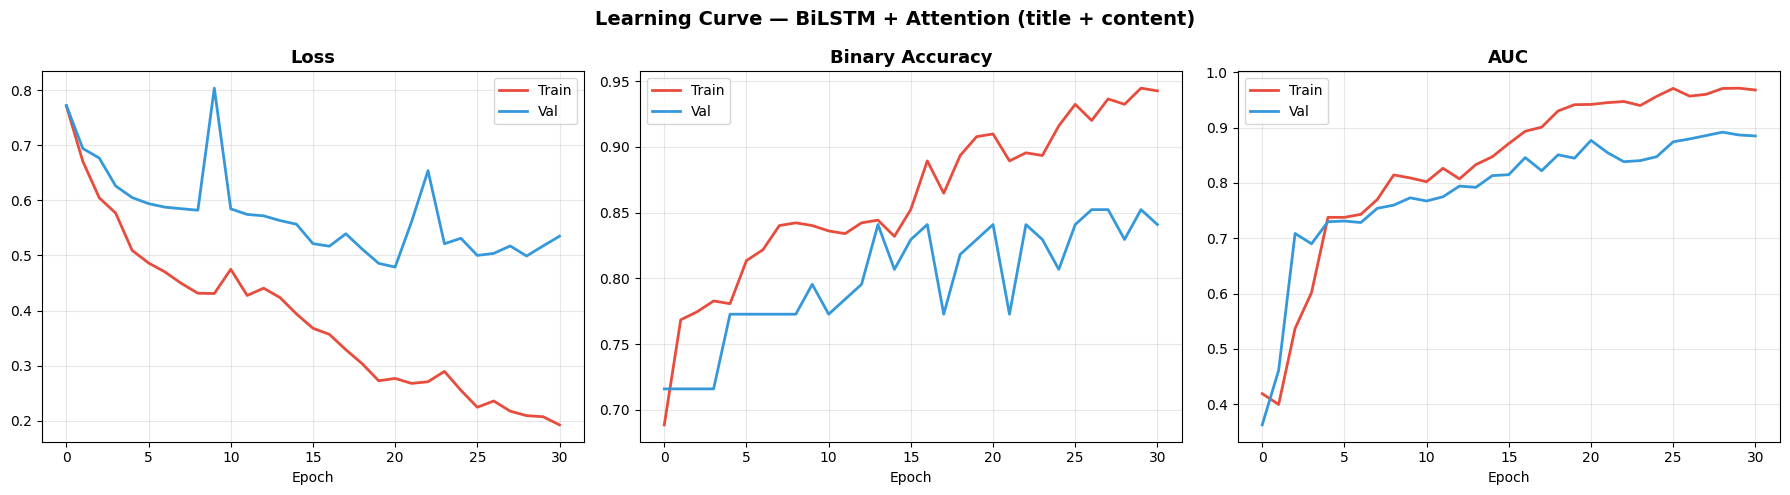

Đã lưu: learning_curve_rnn.png


In [11]:

# ── CELL 11: LEARNING CURVE ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Train', color='#e74c3c', lw=2)
axes[0].plot(history.history['val_loss'], label='Val',   color='#3498db', lw=2)
axes[0].set_title('Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Binary Accuracy
axes[1].plot(history.history['bin_acc'],     label='Train', color='#e74c3c', lw=2)
axes[1].plot(history.history['val_bin_acc'], label='Val',   color='#3498db', lw=2)
axes[1].set_title('Binary Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AUC
axes[2].plot(history.history['auc'],     label='Train', color='#e74c3c', lw=2)
axes[2].plot(history.history['val_auc'], label='Val',   color='#3498db', lw=2)
axes[2].set_title('AUC', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Learning Curve — BiLSTM + Attention (title + content)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curve_rnn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu: learning_curve_rnn.png")


In [23]:
print(history.history)

{'auc': [0.4190598726272583, 0.3995332419872284, 0.5368015766143799, 0.6017646193504333, 0.7377926111221313, 0.7378203868865967, 0.7432277202606201, 0.7700262069702148, 0.8144662380218506, 0.8090606927871704, 0.8022003173828125, 0.8265172839164734, 0.8073248863220215, 0.8332128524780273, 0.8473293781280518, 0.8711870312690735, 0.8934525847434998, 0.9008402228355408, 0.9302040338516235, 0.9414995312690735, 0.9419435858726501, 0.945192813873291, 0.9472398161888123, 0.9400566220283508, 0.956588625907898, 0.9709872007369995, 0.9569851160049438, 0.9601930975914001, 0.9708031415939331, 0.9713554382324219, 0.968071699142456], 'bin_acc': [0.688524603843689, 0.7684426307678223, 0.7745901346206665, 0.7827869057655334, 0.7807376980781555, 0.813524603843689, 0.8217213153839111, 0.8401639461517334, 0.8422130942344666, 0.8401639461517334, 0.8360655903816223, 0.8340163826942444, 0.8422130942344666, 0.8442623019218445, 0.8319672346115112, 0.8524590134620667, 0.8893442749977112, 0.8647540807723999, 0.8

In [12]:


# ── CELL 12: TÌM THRESHOLD TỐI ƯU ──────────────────────────────
y_pred_proba = model.predict(X_test_seq, verbose=0)

best_threshold, best_f1 = 0.5, 0.0

for threshold in np.arange(0.05, 0.95, 0.01):
    y_tmp = (y_pred_proba >= threshold).astype(int)
    for i, row in enumerate(y_tmp):
        if row.sum() == 0:
            y_tmp[i][np.argmax(y_pred_proba[i])] = 1
    f1 = f1_score(y_test, y_tmp, average='macro', zero_division=0)
    if f1 > best_f1:
        best_f1, best_threshold = f1, threshold

print(f"\nThreshold tốt nhất : {best_threshold:.2f}")
print(f"F1-macro tốt nhất  : {best_f1:.4f}")




Threshold tốt nhất : 0.10
F1-macro tốt nhất  : 0.5650


In [13]:

# ── CELL 13: ĐÁNH GIÁ ───────────────────────────────────────────
y_pred_opt = (y_pred_proba >= best_threshold).astype(int)
for i, row in enumerate(y_pred_opt):
    if row.sum() == 0:
        y_pred_opt[i][np.argmax(y_pred_proba[i])] = 1

print(f"\nExact-match Accuracy : {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"Hamming Loss         : {hamming_loss(y_test, y_pred_opt):.4f}  (càng thấp càng tốt)")
print(f"F1-macro             : {f1_score(y_test, y_pred_opt, average='macro',  zero_division=0):.4f}")
print(f"F1-micro             : {f1_score(y_test, y_pred_opt, average='micro',  zero_division=0):.4f}")
print("\n── Báo cáo chi tiết theo nhãn ──")
print(classification_report(y_test, y_pred_opt,
                             target_names=mlb.classes_, zero_division=0))




Exact-match Accuracy : 0.6538
Hamming Loss         : 0.1731  (càng thấp càng tốt)
F1-macro             : 0.5650
F1-micro             : 0.7353

── Báo cáo chi tiết theo nhãn ──
              precision    recall  f1-score   support

   công nghệ       0.33      0.33      0.33         3
    giáo dục       0.86      1.00      0.93        19
    giải trí       0.27      1.00      0.43         3
  kinh doanh       0.50      0.67      0.57         3

   micro avg       0.62      0.89      0.74        28
   macro avg       0.49      0.75      0.57        28
weighted avg       0.70      0.89      0.77        28
 samples avg       0.75      0.88      0.79        28




[công nghệ]  AUC = 0.899  |  Threshold tối ưu (Youden) = 0.00
  → TPR (Recall) = 1.000  |  FPR = 0.130

[giáo dục]  AUC = 1.000  |  Threshold tối ưu (Youden) = 0.43
  → TPR (Recall) = 1.000  |  FPR = 0.000

[giải trí]  AUC = 0.725  |  Threshold tối ưu (Youden) = 0.16
  → TPR (Recall) = 1.000  |  FPR = 0.348

[kinh doanh]  AUC = 0.928  |  Threshold tối ưu (Youden) = 0.07
  → TPR (Recall) = 1.000  |  FPR = 0.130


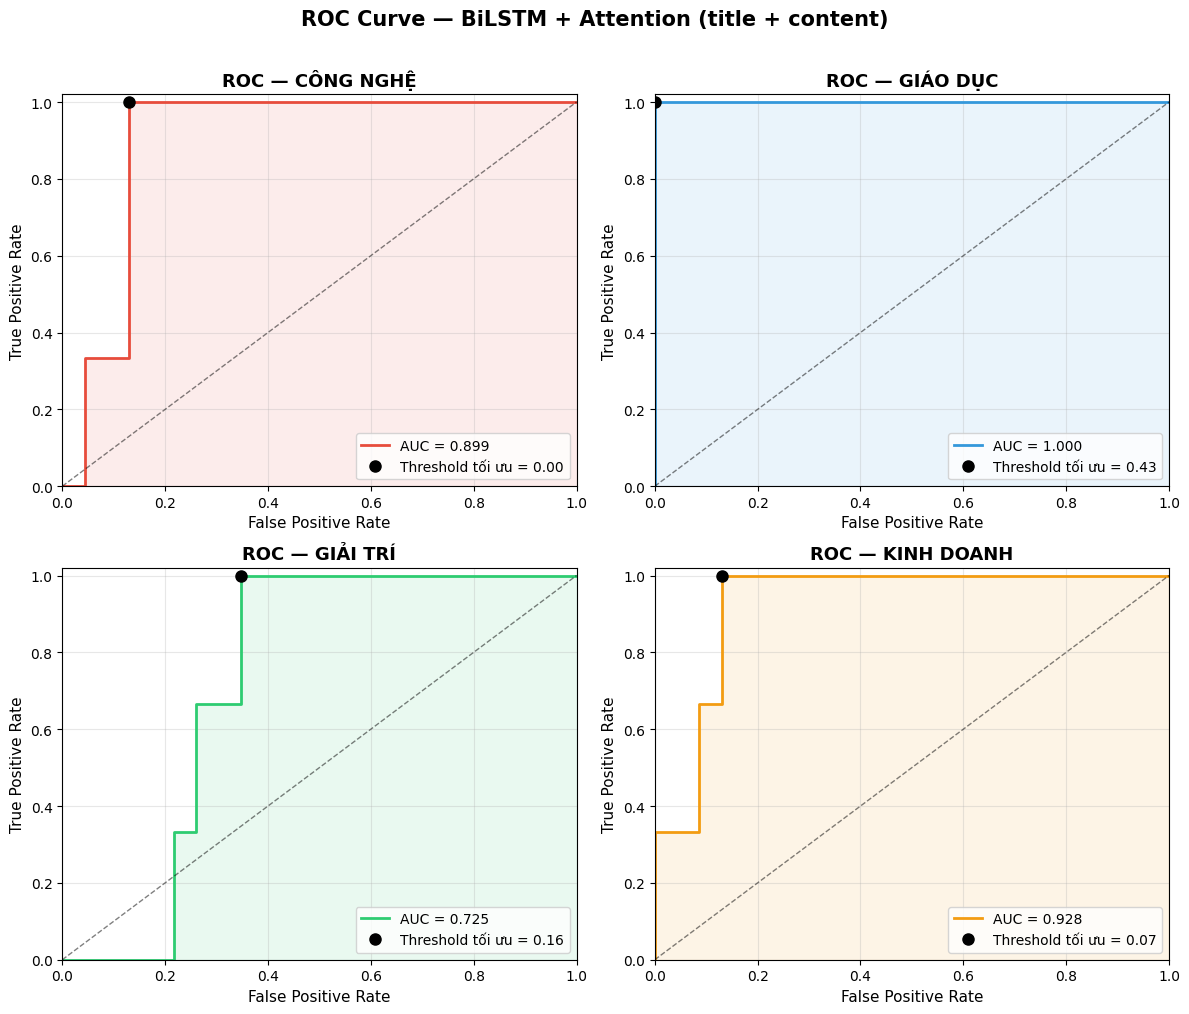


Đã lưu: roc_rnn.png


In [14]:

# ── CELL 14: ROC CURVE ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes   = axes.flatten()
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for i, (cat, color) in enumerate(zip(mlb.classes_, colors)):
    fpr, tpr, thresholds = roc_curve(y_test[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)

    optimal_idx       = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]

    axes[i].plot(fpr, tpr, color=color, lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[i].plot(fpr[optimal_idx], tpr[optimal_idx], 'ko', markersize=8,
                 label=f'Threshold tối ưu = {optimal_threshold:.2f}')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    axes[i].fill_between(fpr, tpr, alpha=0.1, color=color)
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1.02])
    axes[i].set_xlabel('False Positive Rate', fontsize=11)
    axes[i].set_ylabel('True Positive Rate',  fontsize=11)
    axes[i].set_title(f'ROC — {cat.upper()}', fontsize=13, fontweight='bold')
    axes[i].legend(loc='lower right', fontsize=10)
    axes[i].grid(True, alpha=0.3)

    print(f"\n[{cat}]  AUC = {roc_auc:.3f}  |  Threshold tối ưu (Youden) = {optimal_threshold:.2f}")
    print(f"  → TPR (Recall) = {tpr[optimal_idx]:.3f}  |  FPR = {fpr[optimal_idx]:.3f}")

plt.suptitle('ROC Curve — BiLSTM + Attention (title + content)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('roc_rnn.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nĐã lưu: roc_rnn.png")



In [15]:

# ── CELL 15: DỰ ĐOÁN CHI TIẾT ───────────────────────────────────
print("\n── Dự đoán chi tiết (threshold tối ưu) ──\n")
for i in range(len(X_test_raw)):
    true_labels = mlb.inverse_transform(y_test[i].reshape(1, -1))[0]
    pred_labels = mlb.inverse_transform(y_pred_opt[i].reshape(1, -1))[0]

    if   set(true_labels) == set(pred_labels):  status = "✓"
    elif set(pred_labels) &  set(true_labels):  status = "△"
    else:                                        status = "✗"

    # Hiển thị phần tiêu đề (trước [SEP])
    display = X_test_raw[i].split('[SEP]')[0].strip()[:70]
    print(f"[{status}] {display}")
    print(f"    Thật   : {list(true_labels)}")
    print(f"    Dự đoán: {list(pred_labels)}\n")



── Dự đoán chi tiết (threshold tối ưu) ──

[✗] thông_tin giám_đốc_điều_hành gây chú_ý
    Thật   : ['kinh doanh']
    Dự đoán: ['giáo dục', 'giải trí']

[✓] băn_khoăn hiệu_trưởng cắt phụ_cấp ưu_đãi giáo_viên hợp_đồng
    Thật   : ['giáo dục']
    Dự đoán: ['giáo dục']

[△] thông_tin gây chú_ý
    Thật   : ['giải trí']
    Dự đoán: ['công nghệ', 'giải trí', 'kinh doanh']

[✓] tphcm buộc trường hoàn_trả học_phí hơn 2.000 người học
    Thật   : ['giáo dục']
    Dự đoán: ['giáo dục']

[△] thông_tin nợ xấu gây chú_ý
    Thật   : ['kinh doanh']
    Dự đoán: ['công nghệ', 'giải trí', 'kinh doanh']

[✓] scandal ca_sĩ clip cùng nữ_sinh trong khách_sạn
    Thật   : ['giáo dục', 'giải trí']
    Dự đoán: ['giáo dục', 'giải trí']

[✓] giáo_viên tố_dâm ô học_sinh lớp_học thêm
    Thật   : ['giáo dục']
    Dự đoán: ['giáo dục']

[✓] xác_minh đối_tượng đăng_thông_tin sai đề_thi tốt_nghiệp
    Thật   : ['giáo dục']
    Dự đoán: ['giáo dục']

[△] thông_tin robot gây chú_ý
    Thật   : ['công nghệ']
   

In [16]:


# ── CELL 16: VISUALIZE ATTENTION ────────────────────────────────
# Tạo sub-model để lấy attention weights
attention_extractor = Model(
    inputs  = model.input,
    outputs = [
        model.get_layer('attention').output[1],  # (batch, MAX_LEN, 1)
        model.output                              # (batch, 4)
    ]
)

def visualize_attention(title: str, content: str = "", top_n: int = 10):
    """
    Hiển thị top từ quan trọng nhất theo attention weights.
    Dùng để kiểm tra model đang "chú ý" vào đâu.
    """
    combined = build_input(title, content)
    seq = pad_sequences(
        tokenizer.texts_to_sequences([combined]),
        maxlen=MAX_LEN, padding='post'
    )

    attn_weights, proba = attention_extractor.predict(seq, verbose=0)
    attn_weights = attn_weights[0, :, 0]   # (MAX_LEN,)

    # Lấy lại tokens để hiển thị
    tokens = combined.split()
    n = min(len(tokens), MAX_LEN)

    # Top n từ có weight cao nhất
    top_idx = np.argsort(attn_weights[:n])[::-1][:top_n]

    pred_labels = mlb.inverse_transform(
        (proba >= best_threshold).astype(int)
    )[0]

    print(f"\nTiêu đề : {title}")
    if content:
        print(f"Content : {content[:60]}...")
    print(f"Dự đoán : {list(pred_labels)}")
    print(f"\nTop {top_n} từ quan trọng nhất:")
    print(f"  {'Từ':<20} {'Weight':>8}")
    print("  " + "-" * 30)
    for idx in top_idx:
        print(f"  {tokens[idx]:<20} {attn_weights[idx]:>8.4f}")

# Thử nghiệm
visualize_attention(
    title   = "Shark Bình lộ ảnh hẹn hò gây ồn ào trên mạng xã hội",
    content = "Doanh nhân Nguyễn Xuân Phú tức Shark Bình vừa bị tố có mối quan hệ tình cảm ngoài luồng với trợ lý"
)
visualize_attention(
    title = "Ca sĩ nổi tiếng bị tố gian lận tiền từ thiện"
)



Tiêu đề : Shark Bình lộ ảnh hẹn hò gây ồn ào trên mạng xã hội
Content : Doanh nhân Nguyễn Xuân Phú tức Shark Bình vừa bị tố có mối q...
Dự đoán : ['giáo dục']

Top 10 từ quan trọng nhất:
  Từ                     Weight
  ------------------------------
  shark_bình             0.0139
  nguyễn_xuân_phú_tức    0.0139
  doanh_nhân             0.0139
  xã_hội                 0.0139
  [SEP]                  0.0139
  vừa                    0.0139
  mạng                   0.0139
  mối                    0.0139
  tố                     0.0139
  quan_hệ                0.0139

Tiêu đề : Ca sĩ nổi tiếng bị tố gian lận tiền từ thiện
Dự đoán : ['giáo dục', 'giải trí']

Top 10 từ quan trọng nhất:
  Từ                     Weight
  ------------------------------
  từ_thiện               0.0280
  tiền                   0.0248
  nổi_tiếng              0.0162
  gian_lận               0.0159
  tố                     0.0135
  ca_sĩ                  0.0102


In [17]:


# ── CELL 17: LƯU MODEL ──────────────────────────────────────────
model.save('model_rnn.keras')
joblib.dump(
    {
        'tokenizer'     : tokenizer,
        'mlb'           : mlb,
        'best_threshold': best_threshold,
        'max_len'       : MAX_LEN,
        'categories'    : CATEGORIES
    },
    'artifacts_rnn.pkl'
)
print("Đã lưu: model_rnn.keras + artifacts_rnn.pkl")



Đã lưu: model_rnn.keras + artifacts_rnn.pkl


In [18]:

# ── CELL 18: HÀM PREDICT PRODUCTION ────────────────────────────
def predict(titles: list, contents: list = None, threshold: float = None) -> list:
    """
    Predict nhãn cho danh sách tiêu đề.

    Args:
        titles   : list tiêu đề cần predict
        contents : list nội dung tương ứng (optional, để trống nếu chỉ có tiêu đề)
        threshold: ngưỡng quyết định (mặc định dùng best_threshold tìm được)

    Returns:
        list các tuple nhãn, ví dụ [('giải trí',), ('công nghệ', 'kinh doanh')]

    Lưu ý:
        Khi deploy production, chỉ truyền titles, không cần contents.
        Model vẫn hoạt động vì đã học được pattern từ tiêu đề.
    """
    if threshold is None:
        threshold = best_threshold

    if contents is None:
        contents = [''] * len(titles)

    texts = [build_input(t, c) for t, c in zip(titles, contents)]
    seqs  = pad_sequences(
        tokenizer.texts_to_sequences(texts),
        maxlen=MAX_LEN, padding='post', truncating='post'
    )

    proba  = model.predict(seqs, verbose=0)
    binary = (proba >= threshold).astype(int)

    for i, row in enumerate(binary):
        if row.sum() == 0:
            binary[i][np.argmax(proba[i])] = 1

    return mlb.inverse_transform(binary)


# Test production
test_cases = [
    ("Ca sĩ nổi tiếng bị tố gian lận tiền từ thiện", ""),
    ("Startup AI Việt Nam gọi vốn thành công 10 triệu USD", ""),
    ("Giáo viên bị phụ huynh tố đánh học sinh trong lớp", ""),
    ("Mối quan hệ của Phạm Thoại và mẹ bé Bắp", ""),   # case khó — tên nhân vật
]

print("\n── Test predict production ──\n")
results = predict([t for t, _ in test_cases])
for (title, _), tags in zip(test_cases, results):
    print(f"  {title}")
    print(f"  → {list(tags)}\n")


── Test predict production ──

  Ca sĩ nổi tiếng bị tố gian lận tiền từ thiện
  → ['giáo dục', 'giải trí']

  Startup AI Việt Nam gọi vốn thành công 10 triệu USD
  → ['công nghệ', 'giải trí', 'kinh doanh']

  Giáo viên bị phụ huynh tố đánh học sinh trong lớp
  → ['giáo dục', 'giải trí']

  Mối quan hệ của Phạm Thoại và mẹ bé Bắp
  → ['giải trí', 'kinh doanh']

